# Exploratory Data Analysis (EDA)
## Parkinson's Disease Detection — UCI Oxford Dataset
**MCA Final Year Project** · Shivam Kothiyal · H.N.B. Garhwal University

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='Greens_r')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv(os.path.join('..', 'data', 'raw', 'parkinsons.data'))
print('Shape:', df.shape)
df.head()

Shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 1. Dataset Overview

In [2]:
print('=== Basic Info ===')
print(f'Total samples : {len(df)}')
print(f'Features      : {df.shape[1] - 2}  (excluding name and status)')
print(f'Missing values: {df.isnull().sum().sum()}')
print()
print('=== Class Distribution ===')
vc = df['status'].value_counts()
print(f'Parkinson\'s (1): {vc[1]}  ({vc[1]/len(df)*100:.1f}%)')
print(f'Healthy     (0): {vc[0]}  ({vc[0]/len(df)*100:.1f}%)')

=== Basic Info ===
Total samples : 195
Features      : 22  (excluding name and status)
Missing values: 0

=== Class Distribution ===
Parkinson's (1): 147  (75.4%)
Healthy     (0): 48  (24.6%)


## 2. Class Imbalance Visualisation

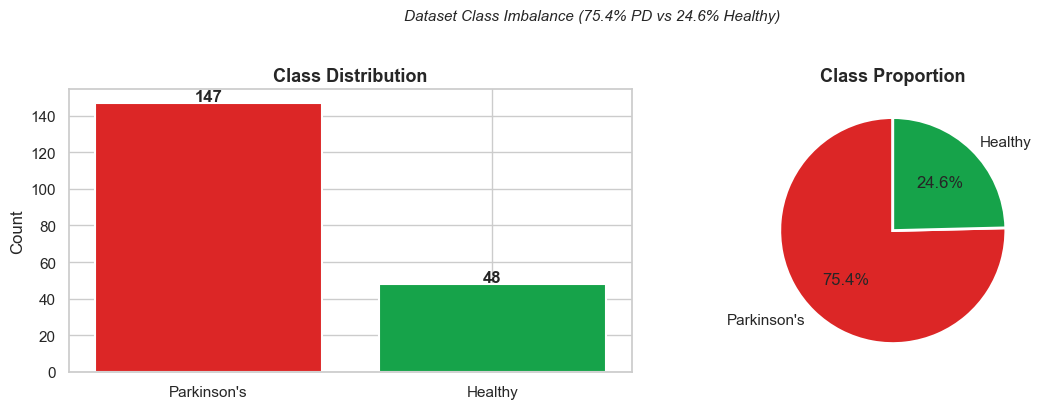

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
labels = ["Parkinson's", 'Healthy']
values = [147, 48]
colors = ['#DC2626', '#16A34A']
axes[0].bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Dataset Class Imbalance (75.4% PD vs 24.6% Healthy)',
             fontsize=11, style='italic', y=1.02)
plt.tight_layout()
plt.show()

## 3. Feature Distributions — PD vs Healthy

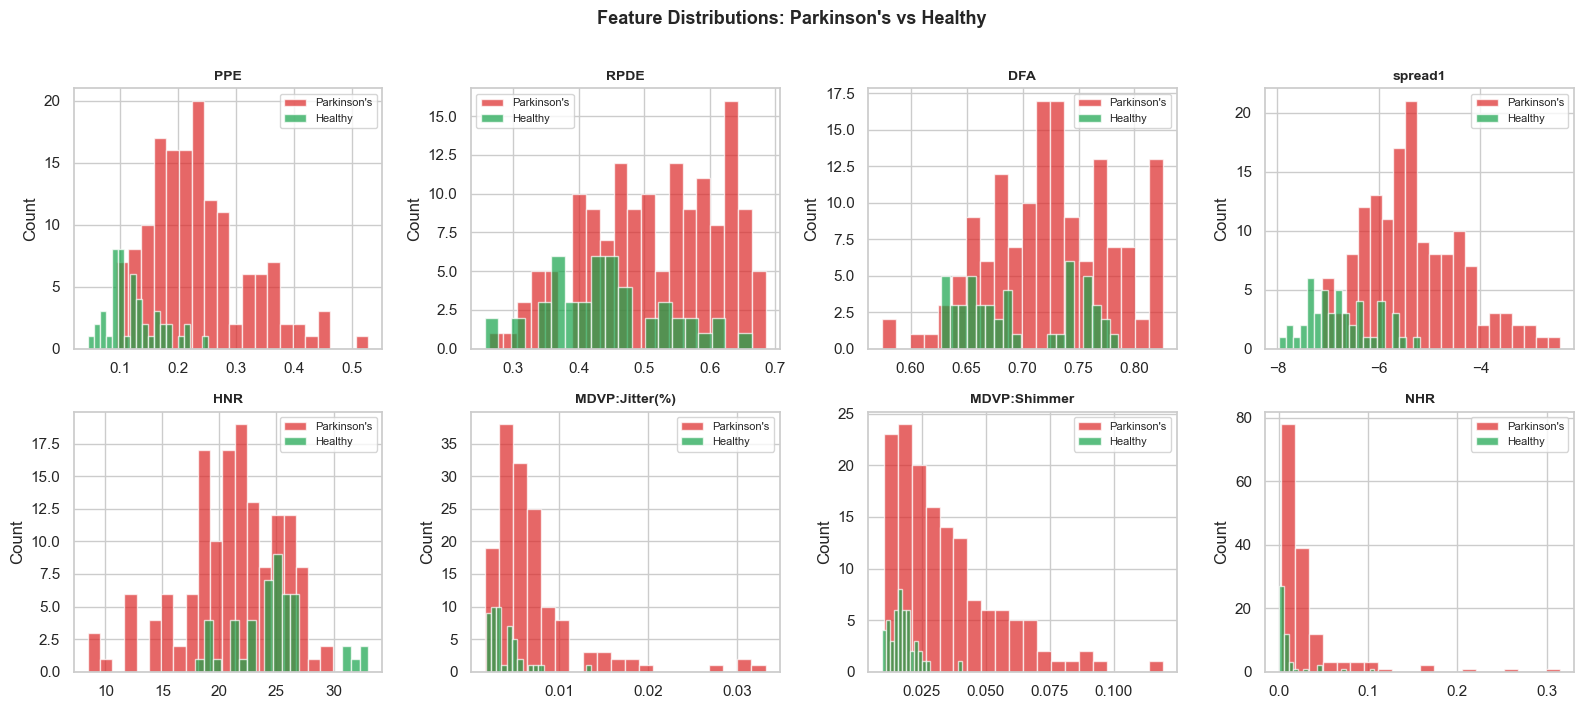

Note: PPE and RPDE show the strongest separation between classes.


In [4]:
key_features = ['PPE', 'RPDE', 'DFA', 'spread1', 'HNR',
                 'MDVP:Jitter(%)', 'MDVP:Shimmer', 'NHR']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    pd_vals  = df[df['status'] == 1][feat]
    hlt_vals = df[df['status'] == 0][feat]
    axes[i].hist(pd_vals,  bins=20, alpha=0.7, color='#DC2626', label="Parkinson's")
    axes[i].hist(hlt_vals, bins=20, alpha=0.7, color='#16A34A', label='Healthy')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions: Parkinson\'s vs Healthy',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Note: PPE and RPDE show the strongest separation between classes.')

## 4. Correlation Heatmap

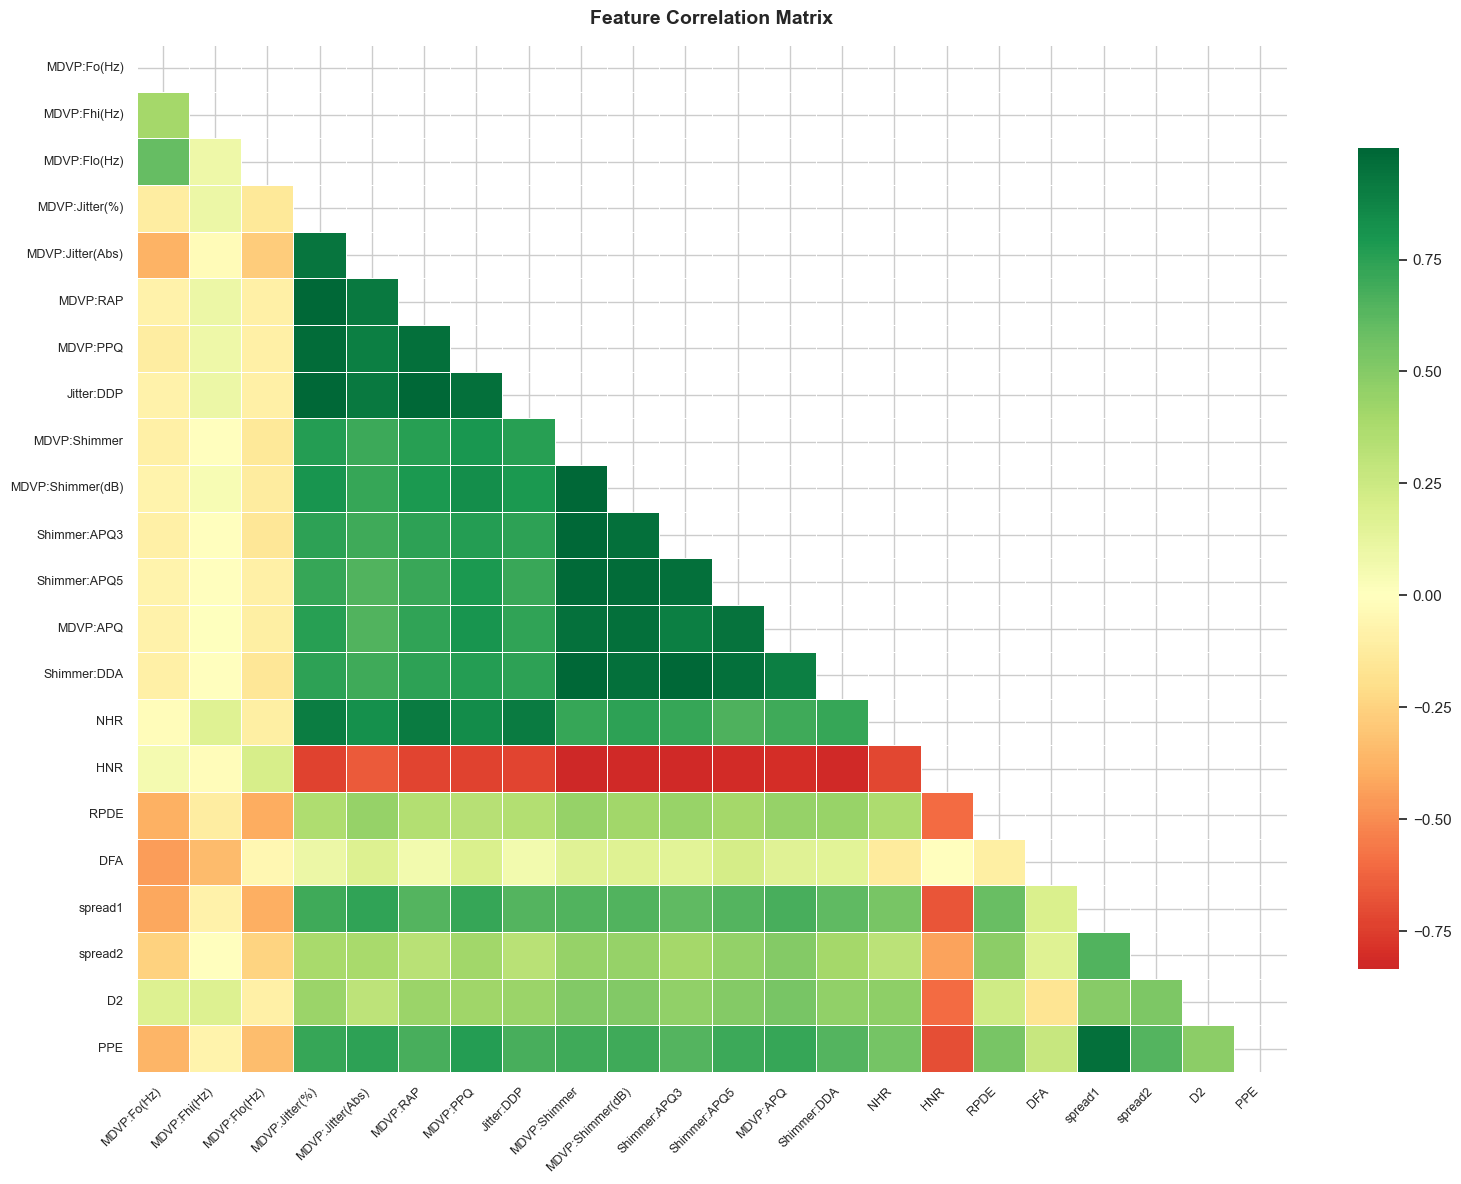

High correlation groups: Jitter features, Shimmer features — expected as they measure related acoustic properties.


In [5]:
features_only = df.drop(['name', 'status'], axis=1)
corr = features_only.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            annot=False, linewidths=0.5, fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()
print('High correlation groups: Jitter features, Shimmer features — expected as they measure related acoustic properties.')

## 5. Feature Correlation with Target (status)

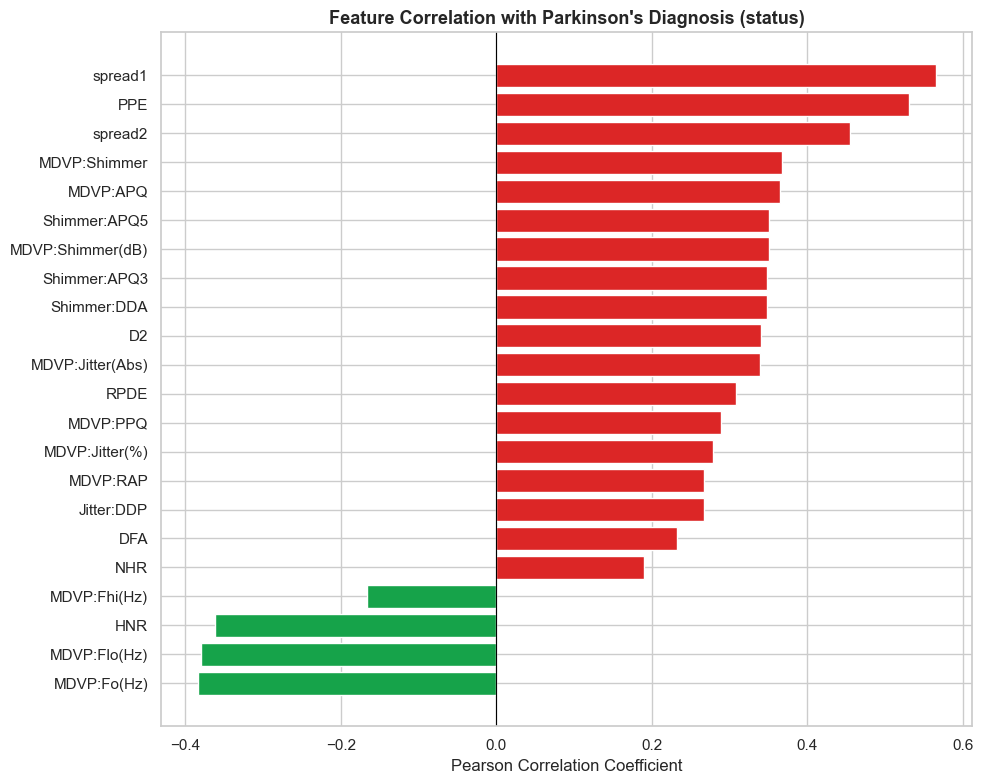

PPE has the highest positive correlation with Parkinson's Disease — confirming it is the most discriminative feature.


In [6]:
target_corr = df.drop(['name'], axis=1).corr()['status'].drop('status').sort_values()

colors = ['#DC2626' if v > 0 else '#16A34A' for v in target_corr.values]
plt.figure(figsize=(10, 8))
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Parkinson\'s Diagnosis (status)',
          fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()
print('PPE has the highest positive correlation with Parkinson\'s Disease — confirming it is the most discriminative feature.')

## 6. Boxplots — Top 6 Discriminative Features

C:\Users\maver\AppData\Local\Temp\ipykernel_3740\2124296275.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_hlt, data_pd],
C:\Users\maver\AppData\Local\Temp\ipykernel_3740\2124296275.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_hlt, data_pd],
C:\Users\maver\AppData\Local\Temp\ipykernel_3740\2124296275.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_hlt, data_pd],
C:\Users\maver\AppData\Local\Temp\ipykernel_3740\2124296275.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotli

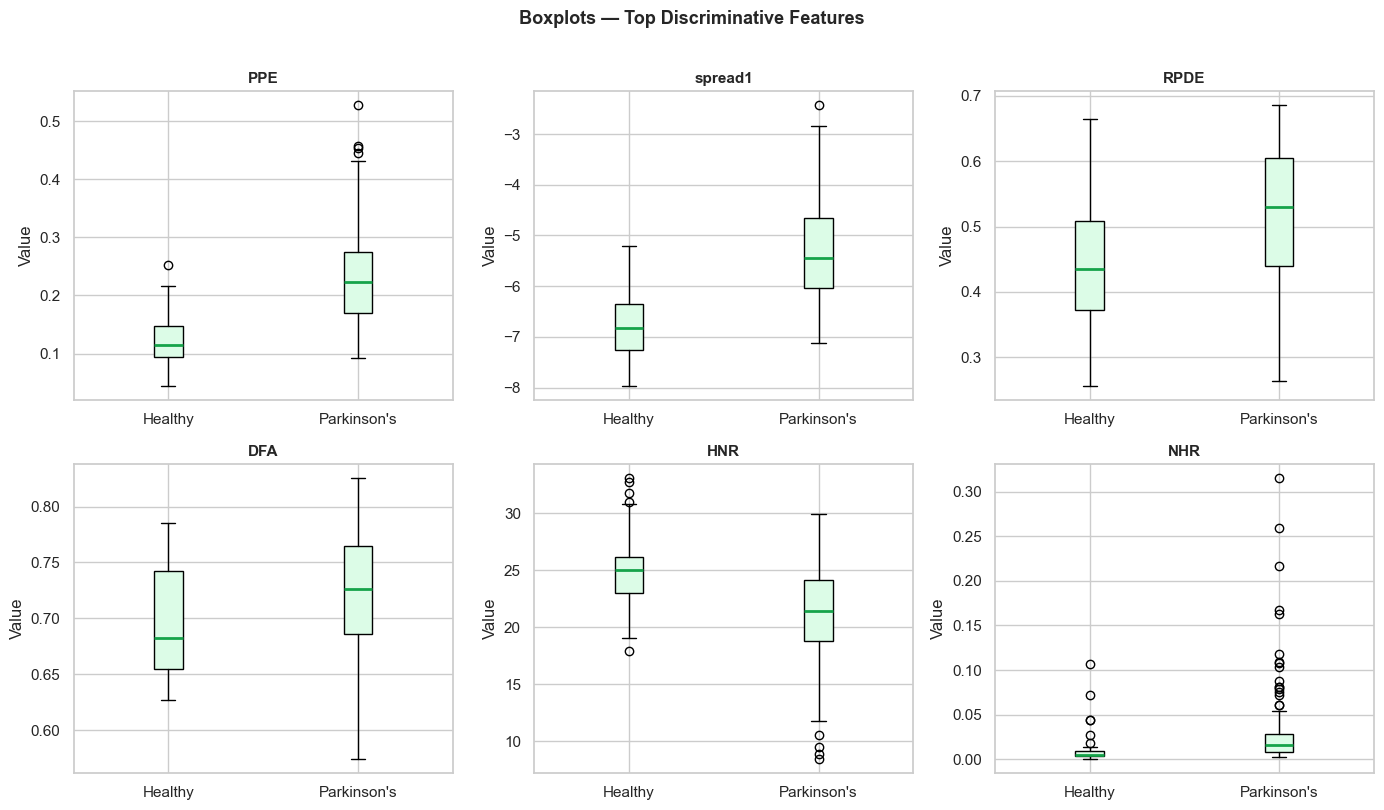

In [7]:
top_feats = ['PPE', 'spread1', 'RPDE', 'DFA', 'HNR', 'NHR']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    data_pd  = df[df['status'] == 1][feat]
    data_hlt = df[df['status'] == 0][feat]
    axes[i].boxplot([data_hlt, data_pd],
                    labels=['Healthy', "Parkinson's"],
                    patch_artist=True,
                    boxprops=dict(facecolor='#DCFCE7'),
                    medianprops=dict(color='#16A34A', linewidth=2))
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Top Discriminative Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Pairplot — Key Features

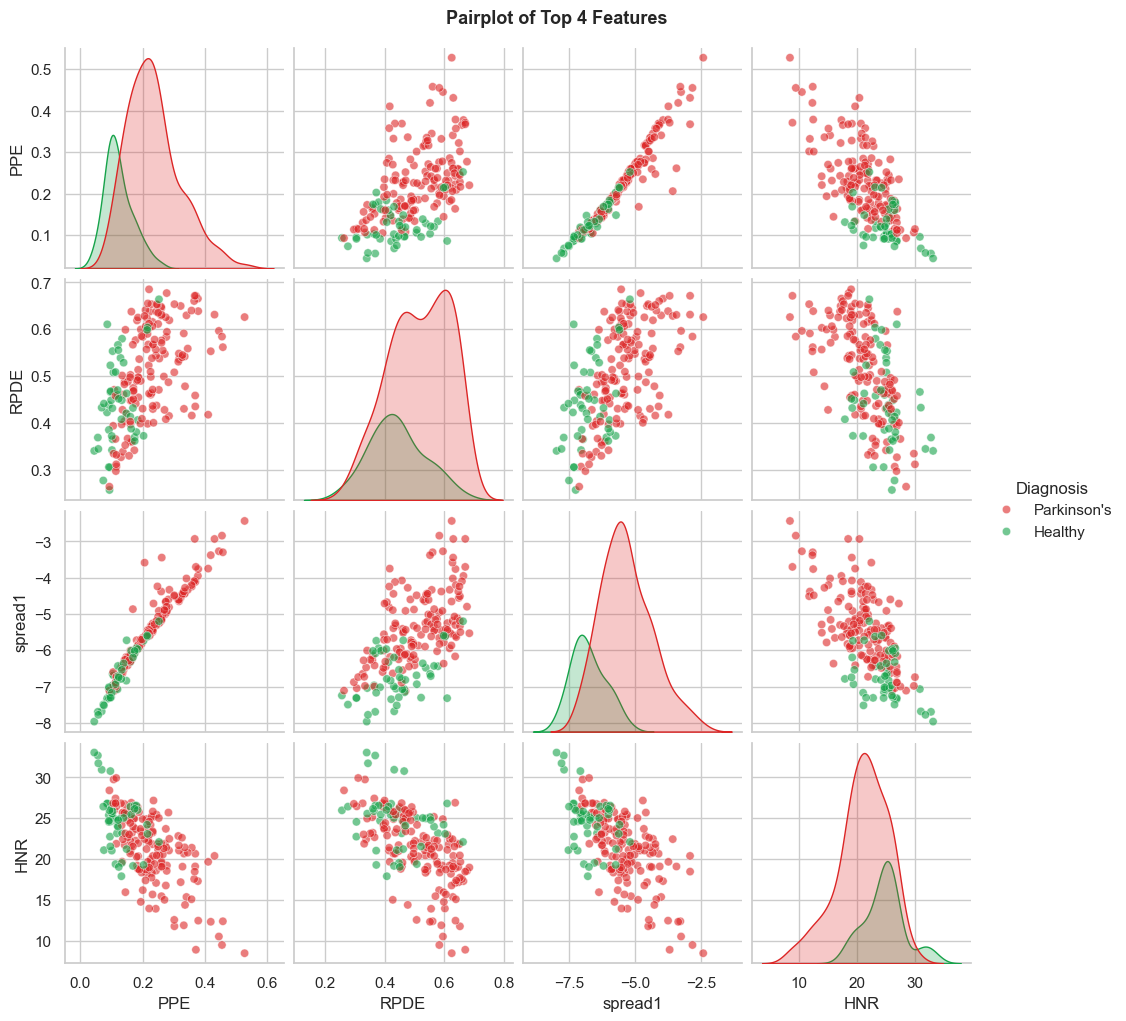

In [8]:
plot_feats = ['PPE', 'RPDE', 'spread1', 'HNR', 'status']
pair_df = df[plot_feats].copy()
pair_df['Diagnosis'] = pair_df['status'].map({1: "Parkinson's", 0: 'Healthy'})

g = sns.pairplot(pair_df.drop('status', axis=1), hue='Diagnosis',
                  palette={"Parkinson's": '#DC2626', 'Healthy': '#16A34A'},
                  diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot of Top 4 Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 8. Statistical Summary — PD vs Healthy

In [9]:
pd_group  = df[df['status'] == 1].drop(['name','status'], axis=1)
hlt_group = df[df['status'] == 0].drop(['name','status'], axis=1)

summary = pd.DataFrame({
    'PD Mean'     : pd_group.mean().round(5),
    'Healthy Mean': hlt_group.mean().round(5),
    'Difference'  : (pd_group.mean() - hlt_group.mean()).round(5),
    'PD Std'      : pd_group.std().round(5),
})
summary['Separation'] = (abs(summary['Difference']) / summary['PD Std']).round(3)
summary.sort_values('Separation', ascending=False).head(10)

,PD Mean,Healthy Mean,Difference,PD Std,Separation
spread1,-5.33342,-6.75926,1.42584,0.97079,1.469
PPE,0.23383,0.12302,0.11081,0.08427,1.315
MDVP:Flo(Hz),106.89356,145.20729,-38.31373,32.27436,1.187
MDVP:Fo(Hz),145.18076,181.93777,-36.75701,32.34805,1.136
spread2,0.24813,0.16029,0.08784,0.07781,1.129
HNR,20.97405,24.67875,-3.70470,4.33914,0.854
MDVP:Shimmer,0.03366,0.01762,0.01604,0.01997,0.803
D2,2.45606,2.15449,0.30157,0.37574,0.803
MDVP:APQ,0.02760,0.01330,0.01430,0.01806,0.792
MDVP:Shimmer(dB),0.32120,0.16296,0.15825,0.20780,0.762


## Summary

| Finding | Detail |
|---|---|
| Best feature | **PPE** (Pitch Period Entropy) — highest correlation + separation |
| Class imbalance | 75.4% PD vs 24.6% Healthy — requires stratified split |
| Correlated groups | Jitter features, Shimmer features (high internal correlation) |
| Missing values | None — dataset is clean |
| Total features | 22 biomedical voice measurements |
